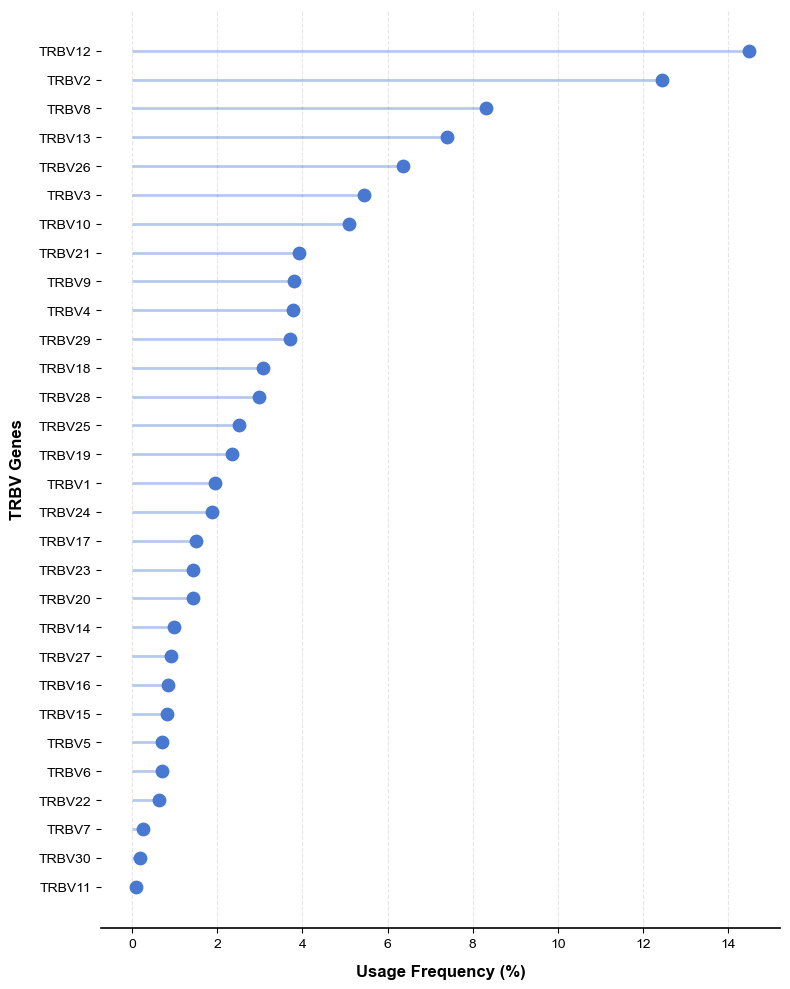

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 模拟 V 基因频率数据 (替换为您的真实数据)
np.random.seed(42)
v_genes = [f'TRBV{i}' for i in range(1, 31)]
# 模拟长尾分布 (少数基因高频，多数低频)
frequencies = np.random.exponential(scale=2.0, size=30)
frequencies = frequencies / frequencies.sum() * 100 # 转换为百分比

df = pd.DataFrame({'Gene': v_genes, 'Frequency': frequencies})
# 核心优化：按频率从大到小排序，这是高级图表的基础逻辑
df = df.sort_values(by='Frequency', ascending=True) 

# 2. 绘图设置
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(figsize=(8, 10)) # 高度拉长，适应众多基因名

# 3. 绘制棒棒糖图 (Lollipop Plot)
# 使用深莫兰迪蓝色
line_color = sns.color_palette("muted")[0] 

# 画横线
ax.hlines(y=df['Gene'], xmin=0, xmax=df['Frequency'], color=line_color, alpha=0.4, linewidth=2)
# 画端点的圆点
ax.scatter(df['Frequency'], df['Gene'], color=line_color, s=80, alpha=1.0)

# 4. 细节美化：极简主义
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # 隐藏Y轴实线，让基因名悬浮
ax.spines['bottom'].set_linewidth(1.2)

ax.set_xlabel("Usage Frequency (%)", fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel("TRBV Genes", fontweight='bold', fontsize=12, labelpad=10)

# 添加垂直虚线作为辅助阅读线，增加专业感
ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig('TRBV_Lollipop_Plot.pdf', dpi=300, bbox_inches='tight')

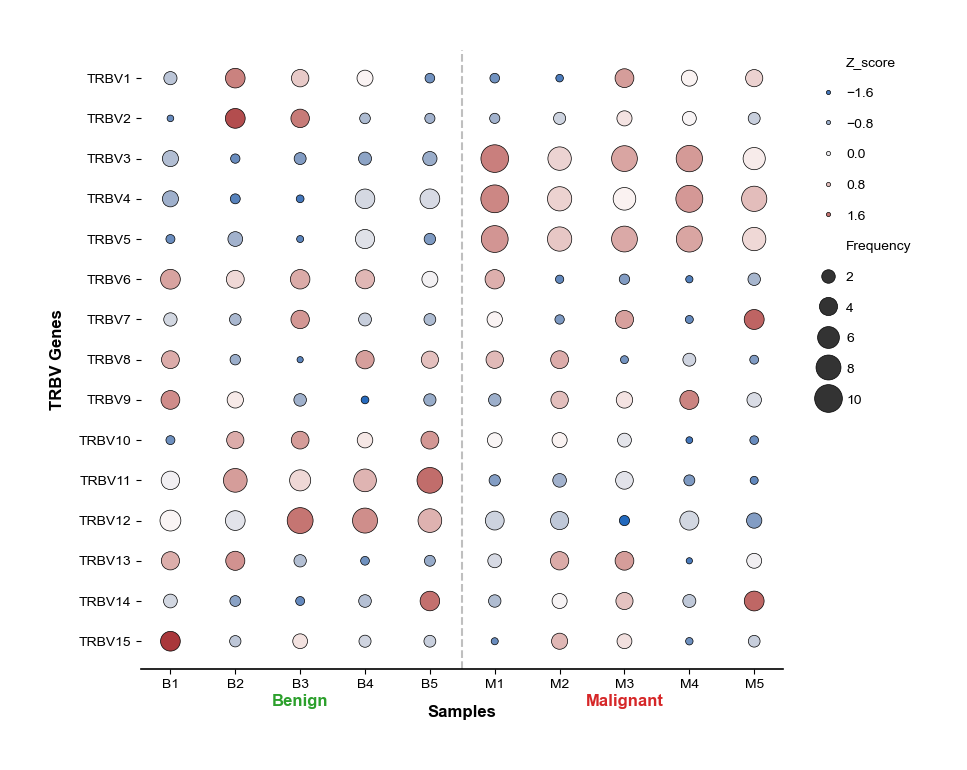

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# ---------------------------------------------------
# 1. 模拟真实的多样本 V 基因数据
# ---------------------------------------------------
np.random.seed(42)
genes = [f'TRBV{i}' for i in range(1, 16)]
# 假设有10个样本：5个良性 (B1-B5)，5个恶性 (M1-M5)
samples_benign = [f'B{i}' for i in range(1, 6)]
samples_malignant = [f'M{i}' for i in range(1, 6)]
samples = samples_benign + samples_malignant

# 模拟频率数据 (0~5%)
data = np.random.rand(len(genes), len(samples)) * 5

# 强行制造显著的生物学差异：
# 让 TRBV3, TRBV4, TRBV5 在恶性肿瘤(M1-M5)中显著扩增
data[2:5, 5:] += 6 
# 让 TRBV11, TRBV12 在良性样本(B1-B5)中显著较高
data[10:12, :5] += 4 

df = pd.DataFrame(data, index=genes, columns=samples)
df.index.name = 'Gene'
df.columns.name = 'Sample'

# ---------------------------------------------------
# 2. 数据转换与标准化 (核心步骤)
# ---------------------------------------------------
# 按行(Gene)计算 Z-score，用于评估相对富集度
df_zscore = df.apply(zscore, axis=1)

# 将宽表融化(Melt)为适合 seaborn 画气泡图的长表格式
df_long = df.reset_index().melt(id_vars='Gene', value_name='Frequency')
df_z_long = df_zscore.reset_index().melt(id_vars='Gene', value_name='Z_score')

# 合并绝对频率和相对 Z-score
df_plot = pd.merge(df_long, df_z_long, on=['Gene', 'Sample'])

# ---------------------------------------------------
# 3. 绘制 SCI 级别气泡点图
# ---------------------------------------------------
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(figsize=(9, 7))

# 绘制散点图
scatter = sns.scatterplot(
    data=df_plot,
    x='Sample',
    y='Gene',
    size='Frequency',     # 气泡大小映射绝对频率
    hue='Z_score',        # 气泡颜色映射相对富集度
    palette='vlag',       # 顶刊最爱的高级冷暖双色渐变 (蓝-白-红)
    sizes=(20, 400),      # 控制气泡的最小和最大尺寸
    edgecolor='black',    # 【秘诀】给气泡加上黑色细边框，质感瞬间提升
    linewidth=0.5,
    ax=ax
)

# ---------------------------------------------------
# 4. 细节美化与排版
# ---------------------------------------------------
# 极简边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)

# 添加分组垂直分割线 (视觉上区分 Benign 和 Malignant)
ax.axvline(x=4.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.5)

# 轴标签优化
ax.set_xlabel("Samples", fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel("TRBV Genes", fontweight='bold', fontsize=12, labelpad=10)

# 在顶部添加分组文字标识
ax.text(2, 15.5, 'Benign', ha='center', va='center', fontweight='bold', fontsize=12, color='#2ca02c')
ax.text(7, 15.5, 'Malignant', ha='center', va='center', fontweight='bold', fontsize=12, color='#d62728')

# 图例剥离与重构 (将 Size 和 Color 的图例分开放在右侧)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, 
          labelspacing=1.2, borderaxespad=0.)

plt.tight_layout()
plt.savefig('TRBV_Bubble_Plot.png', dpi=300, bbox_inches='tight')

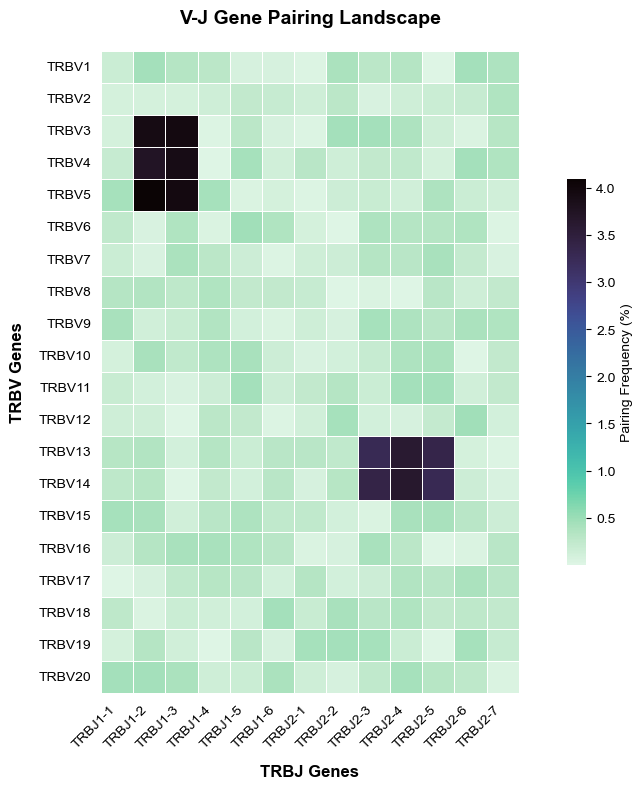

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 模拟 V-J 配对频率数据 (替换为您的真实配对矩阵)
np.random.seed(42)
v_genes = [f'TRBV{i}' for i in range(1, 21)]  # 20 个 V 基因
j_genes = [f'TRBJ{1}-{i}' for i in range(1, 7)] + [f'TRBJ{2}-{i}' for i in range(1, 8)] # 13 个 J 基因

# 模拟背景噪音 (低频配对)
data = np.random.rand(len(v_genes), len(j_genes)) * 0.5

# 模拟特定的 V-J 优势扩增 (在对角线或特定区域制造高频 Hotspots)
data[2:5, 1:3] += 4.0   # TRBV3~5 偏好结合 TRBJ1-2~3
data[12:14, 8:11] += 3.5 # TRBV13~14 偏好结合 TRBJ2-2~4

# 构建 DataFrame
df_vj = pd.DataFrame(data, index=v_genes, columns=j_genes)
df_vj = df_vj.div(df_vj.sum().sum()) * 100 # 转换为总频率百分比

# 2. 绘图设置 (SCI 级别参数)
plt.rcParams['font.sans-serif'] = ['Arial']
# 根据基因数量动态调整画布比例，保证每个格子是正方形
fig, ax = plt.subplots(figsize=(10, 8)) 

# 3. 绘制热图 (核心美学)
# 使用 mako_r (深蓝到亮青色) 或 rocket_r (深紫到亮橙黄)，这是顶刊非常爱用的连续色带
sns.heatmap(
    df_vj, 
    cmap='mako_r', 
    square=True,          # 强制每个热图单元格为正方形 (极其关键的质感来源)
    linewidths=0.5,       # 单元格之间添加极细的分割线
    linecolor='white',    # 分割线为白色，产生清爽的呼吸感
    cbar_kws={
        "shrink": 0.6,    # 缩小图例长度，使其不显得笨重
        "label": "Pairing Frequency (%)", 
        "orientation": "vertical"
    },
    ax=ax
)

# 4. 细节美化
ax.set_xlabel("TRBJ Genes", fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel("TRBV Genes", fontweight='bold', fontsize=12, labelpad=10)

# 刻度标签微调
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# 去除多余的 tick 线条
ax.tick_params(left=False, bottom=False)

plt.title("V-J Gene Pairing Landscape", fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
# plt.savefig('VJ_Pairing_Heatmap.pdf', dpi=300, bbox_inches='tight')